# 01 — Análisis exploratorio: Reconocimiento de Actividades Humanas (HAR)

**Entrega 1 — Propuesta de Proyecto de Machine Learning**

Este notebook reproduce el análisis exploratorio de datos (EDA) que sustenta las cifras y afirmaciones
presentadas en el informe de la propuesta ([`docs/ENTREGA1.PDF`](../docs/ENTREGA1.PDF)): tamaño del
dataset, distribución de clases, verificación de la normalización del vector de 561 características,
forma de las señales inerciales crudas y separación de sujetos entre train/test.

Dataset: [UCI HAR Dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)
(Human Activity Recognition Using Smartphones).

> Diseñado para ejecutarse de forma directa y reproducible en **Google Colab**: clona el repositorio,
> instala dependencias y descarga el dataset automáticamente, sin pasos manuales previos.

In [ ]:
import os

REPO_URL = "https://github.com/garcialvarez/HAR.git"
REPO_DIR = "HAR"

if os.path.basename(os.getcwd()) != REPO_DIR:
    if not os.path.isdir(REPO_DIR):
        !git clone -q {REPO_URL}
    %cd {REPO_DIR}

print("Directorio de trabajo:", os.getcwd())

/private/tmp/colab_sandbox3/Reconocimiento-Actividad
Directorio de trabajo: /private/tmp/colab_sandbox3/Reconocimiento-Actividad


In [2]:
# Instala las dependencias del proyecto (numpy, pandas, scikit-learn, matplotlib).
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Descarga el dataset UCI HAR si aún no está presente.
import os

os.makedirs("data/raw", exist_ok=True)
zip_path = "data/raw/UCI_HAR_Dataset.zip"
dataset_url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

if not os.path.exists(zip_path):
    !curl -sL -o "{zip_path}" "{dataset_url}"

print("Tamaño del .zip descargado: %.1f MB" % (os.path.getsize(zip_path) / 1e6))

Tamaño del .zip descargado: 61.0 MB


In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("src")
from data_loader import ACTIVITY_NAMES, INERTIAL_SIGNALS, load_features, load_raw_signals

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100

# Carga el vector de 561 características ya extraídas por los autores del dataset.
X_train, y_train, subj_train = load_features("train")
X_test, y_test, subj_test = load_features("test")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

X_train: (7352, 561)  |  X_test: (2947, 561)


## 1. Tamaño del dataset

Reproduce la **Tabla 1** de la propuesta: el dataset viene particionado *subject-wise* por los autores
originales (70% de los sujetos para entrenamiento, 30% para prueba), lo que evita fuga de información
entre sujetos.

In [5]:
resumen = pd.DataFrame(
    {
        "Partición": ["Entrenamiento", "Prueba", "Total"],
        "# Sujetos": [
            subj_train.nunique(),
            subj_test.nunique(),
            pd.concat([subj_train, subj_test]).nunique(),
        ],
        "# Ventanas": [len(X_train), len(X_test), len(X_train) + len(X_test)],
        "# Features": [X_train.shape[1], X_test.shape[1], X_train.shape[1]],
    }
)
resumen

,Partición,# Sujetos,# Ventanas,# Features
0,Entrenamiento,21,7352,561
1,Prueba,9,2947,561
2,Total,30,10299,561


## 2. Distribución de clases

Reproduce la **Tabla 2** de la propuesta. El dataset está razonablemente balanceado
(ratio máx/mín ≈ 1.43 en train), por lo que *accuracy* es una métrica interpretable sin ajustes
adicionales.

In [6]:
def distribucion(y):
    counts = y.value_counts().reindex(ACTIVITY_NAMES.values())
    pct = (counts / counts.sum() * 100).round(1)
    return counts, pct


train_counts, train_pct = distribucion(y_train)
test_counts, test_pct = distribucion(y_test)

dist_df = pd.DataFrame(
    {"Train": train_counts, "Train %": train_pct, "Test": test_counts, "Test %": test_pct}
)
print(f"Ratio máx/mín (train): {train_counts.max() / train_counts.min():.2f}")
dist_df

Ratio máx/mín (train): 1.43


,Train,Train %,Test,Test %
activity_id,,,,
WALKING,1226,16.7,496,16.8
WALKING_UPSTAIRS,1073,14.6,471,16.0
WALKING_DOWNSTAIRS,986,13.4,420,14.3
SITTING,1286,17.5,491,16.7
STANDING,1374,18.7,532,18.1
LAYING,1407,19.1,537,18.2


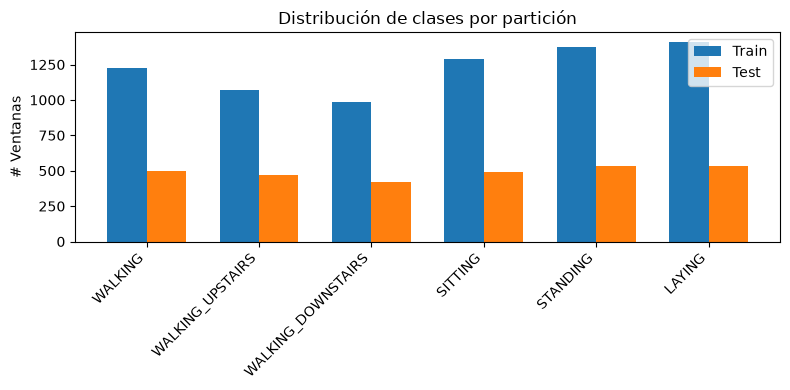

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ACTIVITY_NAMES))
width = 0.35
ax.bar(x - width / 2, train_counts.values, width, label="Train")
ax.bar(x + width / 2, test_counts.values, width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha="right")
ax.set_ylabel("# Ventanas")
ax.set_title("Distribución de clases por partición")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Verificación de normalización del vector de 561 features

La propuesta afirma que las 561 características (dominio tiempo/frecuencia) ya vienen
normalizadas en el rango $[-1, 1]$. Lo verificamos directamente sobre los datos.

Valor mínimo global: -1.0000
Valor máximo global:  1.0000


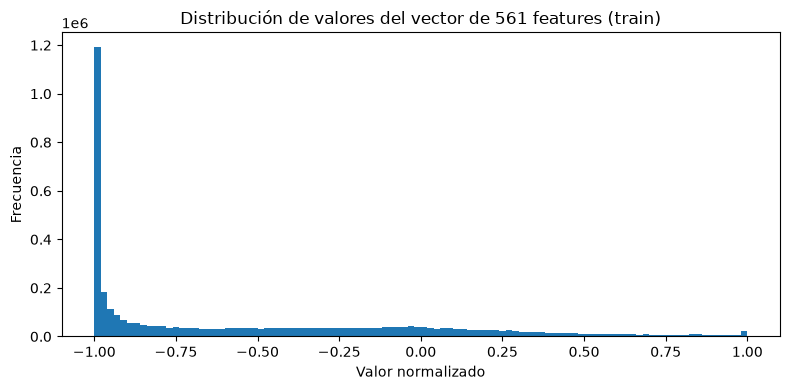

In [8]:
print(f"Valor mínimo global: {X_train.min().min(): .4f}")
print(f"Valor máximo global: {X_train.max().max(): .4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train.values.ravel(), bins=100)
ax.set_title("Distribución de valores del vector de 561 features (train)")
ax.set_xlabel("Valor normalizado")
ax.set_ylabel("Frecuencia")
fig.tight_layout()
plt.show()

## 4. Señales inerciales crudas

Además del vector de features, el dataset ofrece las señales crudas: 9 canales
(aceleración total y corporal en X/Y/Z, velocidad angular en X/Y/Z) × 128 pasos temporales por
ventana (2.56 s a 50 Hz). Estas son las señales que usarían modelos de deep learning
(CNN/RNN) en etapas posteriores del proyecto, en vez del vector de features ya calculado.

Forma de las señales crudas (train): (7352, 128, 9)  (ventanas, pasos, canales)
Canales disponibles: ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


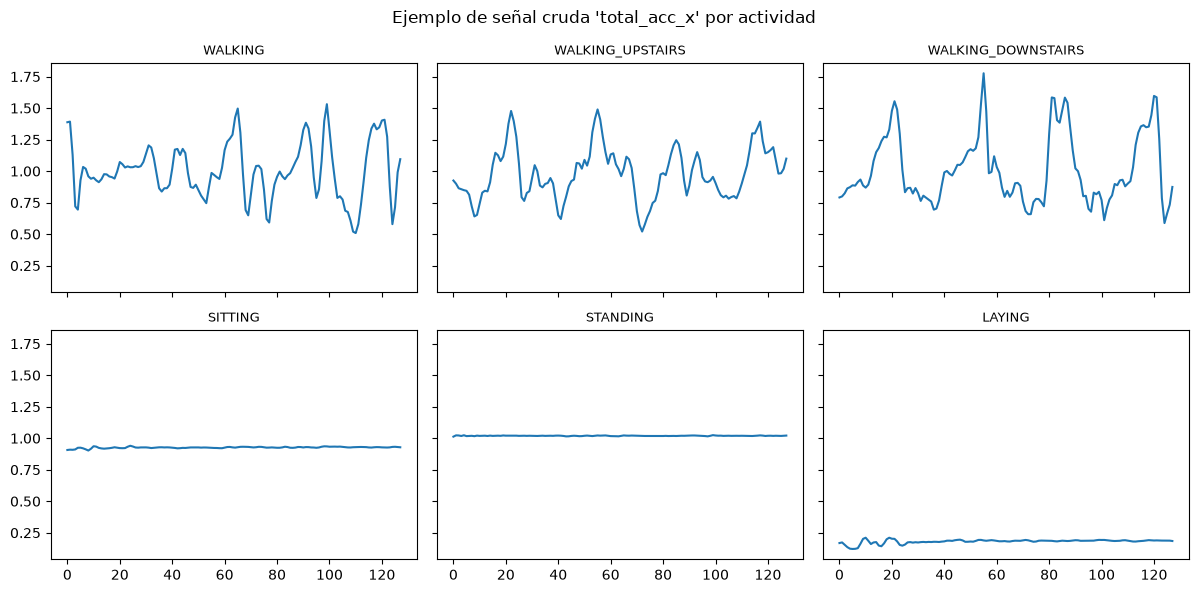

In [9]:
X_raw_train, y_raw_train, _ = load_raw_signals("train")
print(f"Forma de las señales crudas (train): {X_raw_train.shape}  (ventanas, pasos, canales)")
print(f"Canales disponibles: {INERTIAL_SIGNALS}")

channel_idx = INERTIAL_SIGNALS.index("total_acc_x")
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, act in zip(axes.ravel(), ACTIVITY_NAMES.values()):
    idx = y_raw_train[y_raw_train == act].index[0]
    ax.plot(X_raw_train[idx, :, channel_idx])
    ax.set_title(act, fontsize=9)
fig.suptitle("Ejemplo de señal cruda 'total_acc_x' por actividad")
fig.tight_layout()
plt.show()

## 5. Separación de sujetos entre train y test

Confirmamos que la partición es *subject-wise*: ningún sujeto aparece en ambas particiones,
lo que evita fuga de información entre entrenamiento y prueba.

In [10]:
sujetos_train = sorted(subj_train.unique())
sujetos_test = sorted(subj_test.unique())
overlap = set(sujetos_train) & set(sujetos_test)

print(f"Sujetos train ({len(sujetos_train)}): {sujetos_train}")
print(f"Sujetos test  ({len(sujetos_test)}): {sujetos_test}")
print(f"Sujetos en ambas particiones: {sorted(overlap) if overlap else 'ninguno'}")

assert len(overlap) == 0, "Se esperaba que train y test no compartieran sujetos"


Sujetos train (21): [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Sujetos test  (9): [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]
Sujetos en ambas particiones: ninguno


## Conclusiones

- El dataset tiene **10,299 ventanas** (7,352 train / 2,947 test) de **561 features** cada una,
  provenientes de **30 sujetos** particionados *subject-wise* (21 train / 9 test), sin solapamiento.
- Las clases están **razonablemente balanceadas** (ratio máx/mín ≈ 1.43), confirmando que *accuracy*
  es una métrica interpretable como métrica principal, complementada con F1 por clase.
- El vector de 561 features está efectivamente normalizado en **[-1, 1]**, como describe la propuesta.
- Las señales crudas tienen la forma esperada **(ventanas, 128, 9)**, listas para alimentar directamente
  a arquitecturas de deep learning (CNN/RNN) en etapas posteriores del proyecto.

Estos resultados son consistentes con los descritos en [`docs/ENTREGA1.PDF`](../docs/ENTREGA1.PDF) y
sientan la base de datos sobre la cual se entrenarán y compararán los modelos (línea base y arquitecturas
de deep learning) en las siguientes entregas.